# Contextual Rejection Model

## An independent answer to “which track and artist do I reject most?”

This notebook does **not** reuse the prior skip-rate or completion-ratio rankings. It works directly from every `Streaming_History_*.json` export and uses Rewind’s enriched `track_features` metadata, treating “hate” as a behavioral inference rather than a fact Spotify records.

### The idea

A strong negative signal is an **explicit forward skip before meaningful completion**. Metadata makes “meaningful” relative to each track’s real catalog duration rather than a fixed number of seconds. The signal is only meaningful in context:

- A track started with `clickrow` or `playbtn` was deliberately selected, so it is not used as a forced-exposure trial.
- Passive trials are limited to known continuation, skip-through, and app-resume starts.
- The model compares tracks only against plays with the same start mechanism, shuffle state, and duration band.
- It collapses repeated events within a listening session, so a skip spiral cannot become dozens of independent votes.
- Deliberately selecting an entity is counterevidence, not proof of dislike.
- A track needs statistical evidence and minimum support before it can win.
- An artist is reported only when the evidence spans multiple rejected tracks.

The result is an auditable *contextual rejection* ranking. It can say “the data are insufficient” rather than manufacture certainty.

### Cell: imports

**What it does:** loads the Python tools used throughout the notebook.

**How it does it:** `Counter` and `defaultdict` summarize events; `Path` locates files; `json` reads Spotify exports; `datetime` is imported later for times; `unicodedata` normalizes fallback text IDs; and `duckdb` reads Rewind's enriched track metadata. The math, random, and statistics imports are for the later scoring and uncertainty sections.

**Bigger picture:** this cell only makes capabilities available. It does not read data or make any conclusion.

In [2]:
# This notebook uses the enriched per-session metadata already created by Rewind.
# DuckDB is a project dependency in backend/.venv; select that kernel if this import fails.
from collections import Counter, defaultdict
from math import erfc, sqrt
from pathlib import Path
import json
import random
import statistics
import unicodedata

import duckdb

### Cell: paths and `CONFIG`

**What it does:** identifies the project data, chooses the enriched session database, creates an output folder, and records every modelling assumption in one dictionary.

**How it does it:** `Path.cwd().parent` moves from `notebooks/` to the project root. The existence check stops immediately if the selected DuckDB file is missing. `CONFIG` stores thresholds instead of scattering magic numbers through later cells.

**Bigger picture:** changing an assumption here changes the downstream model reproducibly. For example, `rapid_completion=0.30` means “before 30% of the real track duration,” while `session_gap_minutes=30` defines when a new listening session begins.

In [3]:
path = Path.cwd().parent

DATA_DIR = path / "data"
SESSION_DB = DATA_DIR / "sessions" / "27167b66-2132-4696-8730-042babd57810.duckdb"
EXPORT_DIR = path / "notebooks" / "outputs" / "contextual_rejection"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if not SESSION_DB.is_file():
    raise FileNotFoundError(
        f"Missing enriched session database: {SESSION_DB}. "
        "Upload the exports in Rewind once so track_features is created."
    )

CONFIG = {
    "rapid_completion": 0.30,
    "choice_starts": frozenset({"clickrow", "playbtn"}),
    "clear_ends": frozenset({"trackdone", "fwdbtn"}),
    "session_gap_minutes": 30,
    "prior_strength": 20.0,
    "track_min_exposures": 10,
    "track_min_rejections": 4,
    "artist_min_exposures": 30,
    "artist_min_rejections": 8,
    "artist_min_tracks": 2,
    "track_min_excess_rate": 0.10,
    "artist_min_excess_rate": 0.08,
    "max_false_discovery_rate": 0.05,
    "bootstrap_samples": 250,
    "random_seed": 20260911,
}

print(f"Project root: {path}")
print(f"Metadata source: {SESSION_DB}")
print(f"Exports will be written to: {EXPORT_DIR}")
print("Rapid rejection: forward skip before 30% of the catalog duration")

Project root: /home/kala/Documents/rewind
Metadata source: /home/kala/Documents/rewind/data/sessions/27167b66-2132-4696-8730-042babd57810.duckdb
Exports will be written to: /home/kala/Documents/rewind/notebooks/outputs/contextual_rejection
Rapid rejection: forward skip before 30% of the catalog duration


## How to Read the First Three Sections

These sections prepare evidence. They **do not rank any track or artist yet**. Each raw Spotify record gradually becomes one enriched `play` record that later sections can compare fairly.

### 1. Configure the analysis

The preceding cell sets file locations and `CONFIG`, the notebook's list of explicit assumptions.

- `rapid_completion = 0.30` means a playback must end before 30% completion to be considered *rapid*.
- `choice_starts = {"clickrow", "playbtn"}` means you deliberately chose the track. A chosen track is not treated as an unwanted recommendation.
- `session_gap_minutes = 30` means a gap longer than 30 minutes starts a new listening session. Repeated skips inside one session will later be reduced to one trial.
- The remaining minimum-count, false-discovery, and bootstrap settings only affect the later ranking and uncertainty checks.

**Output of this part:** paths to the raw export files and metadata database, plus one transparent set of model assumptions.

### 2. Load, clean, and enrich the raw Spotify events

Each JSON row is one playback event, not necessarily one song you intentionally selected. The next cells:

1. read every `Streaming_History_*.json` export into `raw_rows`;
2. keep records with `spotify_track_uri` in `music_rows`;
3. remove exact duplicate records, producing `unique_music_rows`;
4. extract the Spotify ID from each URI; and
5. look up catalog metadata in DuckDB, producing `metadata_by_id`.

The metadata lookup provides the actual track duration. That lets the notebook compare a 30-second listen to a two-minute track differently from a 30-second listen to a six-minute track. Missing metadata is reported and excluded from duration-based scoring; the notebook never invents a duration.

**Output of this part:** a de-duplicated set of music events and a fast lookup table of track metadata.

### 3. Build comparable behavior signals

The next cells sort events by time, assign a session number, and convert each export row into a `play` dictionary. Important fields are:

| Field | Meaning | Why it matters later |
| --- | --- | --- |
| `completion` | `ms_played / catalog_duration`, capped at 1 | Makes playback comparable across track lengths |
| `chosen` | Started with `clickrow` or `playbtn` | Evidence that you actively wanted the track |
| `passively_served` | Started by continuation, skip-through, or app resume | The track was presented without an explicit selection |
| `rapid_rejection` | Passive exposure, explicit forward skip, and at most 30% completion | The negative behavioral label |
| `durable_acceptance` | At least 80% completion | Positive counterevidence |
| `context` | Start mechanism, shuffle state, and duration band | Ensures later comparisons are like-for-like |

A `backbtn` is not a rejection because it can mean replaying a previous track. Similarly, a late forward skip is not labelled rapid rejection: it may simply mean you had already heard most of the song.

**Output of this part:** `plays`, an enriched sequence of listening events with transparent behavioral labels.

### Cell: find and load the export files

**What it does:** gathers every Spotify history JSON file and combines their rows into `raw_rows`.

**How it does it:** `glob("Streaming_History_*.json")` finds matching files, `sorted` makes their order deterministic, and `json.load` converts each file into Python dictionaries. `raw_rows.extend(part)` appends every file's list instead of nesting lists. `track_id_from_uri` keeps only the final part of a URI such as `spotify:track:abc123`, giving the reusable ID `abc123`.

**Bigger picture:** `raw_rows` is intentionally broad: it preserves every exported record first. Filtering happens in the next cell so we can measure exactly what was removed.

In [4]:
from datetime import datetime

# Load and process streaming history JSON files from the data directory


def track_id_from_uri(track_uri):
    if not track_uri:
        return None
    return track_uri.rsplit(":", 1)[-1]


source_files = sorted(DATA_DIR.glob("Streaming_History_*.json"))
if not source_files:
    raise FileNotFoundError(f"No Streaming_History_*.json files found in {DATA_DIR}")

raw_rows = []
for path in source_files:
    with path.open(encoding="utf-8") as handle:
        part = json.load(handle)
    raw_rows.extend(part)
    print(f"{path.name}: {len(part):,} rows")

Streaming_History_Audio_2022.json: 61 rows
Streaming_History_Audio_2023.json: 3,984 rows
Streaming_History_Audio_2024.json: 11,734 rows
Streaming_History_Audio_2025.json: 2,898 rows
Streaming_History_Audio_2026.json: 5,634 rows


### Cell: keep music and remove exact duplicates

**What it does:** turns all export rows into `music_rows`, then into the de-duplicated `unique_music_rows` used by the analysis.

**How it does it:** a row is kept only when it has `spotify_track_uri`, Spotify's strongest signal that the row represents a track. The five-part `fingerprint` combines timestamp, track URI, play duration, start reason, and end reason. A `set` named `seen` remembers fingerprints already encountered, so repeated copies are ignored.

**Bigger picture:** one duplicated export row must not count as two listening events. This cell protects every later rate and ranking from that simple inflation.

In [5]:
# Filter out unique music rows based on a fingerprint of key attributes
music_rows = [row for row in raw_rows if row.get("spotify_track_uri")]
seen = set()
unique_music_rows = []
for row in music_rows:
    fingerprint = (
        row.get("ts"), row.get("spotify_track_uri"), row.get("ms_played"),
        row.get("reason_start"), row.get("reason_end"),
    )
    if fingerprint not in seen:
        seen.add(fingerprint)
        unique_music_rows.append(row)

duplicate_count = len(music_rows) - len(unique_music_rows)

print(f"\nAll export rows: {len(raw_rows):,}")
print(f"Music rows: {len(music_rows):,}")
print(f"Exact duplicate music rows removed: {duplicate_count:,}")


All export rows: 24,311
Music rows: 24,305
Exact duplicate music rows removed: 64


### Cell: visualize the filtering pipeline

**What it does:** draws three bars for all exported rows, rows with a track URI, and de-duplicated music events.

**How it does it:** it packages the three counts into a small pandas table, then Seaborn draws the bars. The loop over `ax.patches` places the exact count above each bar; the remaining lines only control chart labels and spacing.

**Bigger picture:** this is an audit visualization, not model evidence. It shows whether cleaning discarded a suspiciously large amount of history before any behavioral inference is made.

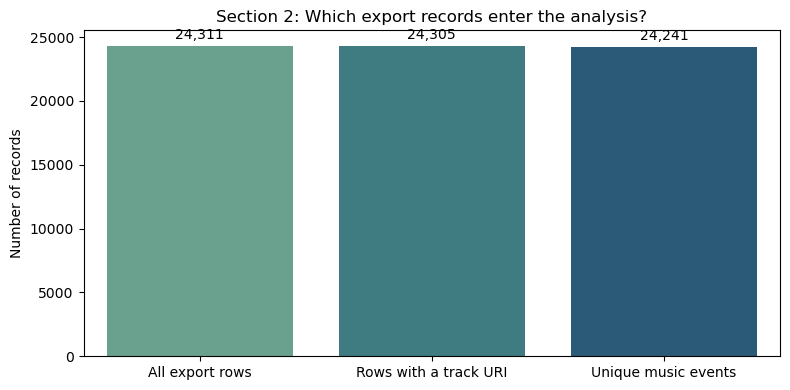

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

filter_counts = pd.DataFrame(
    {
        "stage": ["All export rows", "Rows with a track URI", "Unique music events"],
        "events": [len(raw_rows), len(music_rows), len(unique_music_rows)],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=filter_counts, x="stage", y="events", hue="stage", palette="crest", legend=False, ax=ax)
for bar, count in zip(ax.patches, filter_counts["events"]):
    ax.annotate(
        f"{count:,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
ax.set(
    title="Section 2: Which export records enter the analysis?",
    xlabel="",
    ylabel="Number of records",
)
ax.ticklabel_format(axis="y", style="plain")
plt.tight_layout()
plt.show()

### Cell: inspect available fields and missing values

**What it does:** discovers every column present in the raw exports and counts missing values for each column among music rows.

**How it does it:** the set comprehension collects keys from every raw dictionary; `sorted` makes the printed list stable. The dictionary comprehension then asks, for each column, how many music rows contain `None` or an empty string.

**Bigger picture:** the model can only use evidence the export actually contains. This audit tells us which fields are trustworthy enough to use and prevents silently relying on a mostly empty column.

In [7]:

all_columns = sorted({column for row in raw_rows for column in row})
missing = {
    column: sum(row.get(column) in (None, "") for row in music_rows)
    for column in all_columns
}
print(f"Available columns ({len(all_columns)}): {', '.join(all_columns)}")

Available columns (23): audiobook_chapter_title, audiobook_chapter_uri, audiobook_title, audiobook_uri, conn_country, episode_name, episode_show_name, incognito_mode, ip_addr, master_metadata_album_album_name, master_metadata_album_artist_name, master_metadata_track_name, ms_played, offline, offline_timestamp, platform, reason_end, reason_start, shuffle, skipped, spotify_episode_uri, spotify_track_uri, ts


### Cell: read enriched catalog metadata

**What it does:** opens the selected DuckDB database and retrieves the metadata fields needed later.

**How it does it:** the `with` block opens DuckDB in `read_only=True` mode, so the notebook cannot change Rewind's data. It first checks that `track_features` exists, then runs a SQL `SELECT` for track ID, duration, canonical artist ID/name, and descriptive fields such as genre and audio features. `fetchall()` returns the SQL rows to Python as `feature_rows`.

**Bigger picture:** Spotify history says how long something played; the catalog says how long the track is. Joining those two sources is what makes completion a fair relative measure.

In [8]:
with duckdb.connect(str(SESSION_DB), read_only=True) as metadata_con:
    table_exists = metadata_con.execute(
        "SELECT COUNT(*) FROM information_schema.tables WHERE table_name = 'track_features'"
    ).fetchone()[0]
    if not table_exists:
        raise RuntimeError("The session database has no track_features table. Re-upload the exports first.")
    feature_rows = metadata_con.execute(
        """
        SELECT
            track_id, duration, artist_id, artist_name, artist_genres, popularity,
            release_year, danceability, energy, valence
        FROM track_features
        """
    ).fetchall()



### Cell: build `metadata_by_id` and audit the join

**What it does:** converts SQL rows into a dictionary keyed by Spotify `track_id`, then counts how many cleaned music events find a metadata match.

**How it does it:** the dictionary comprehension reshapes each tuple from `feature_rows` into a named dictionary such as `metadata_by_id[track_id]["duration_s"]`. The `sum(...)` expression extracts each event's URI ID and counts whether that ID is present as a key.

**Bigger picture:** dictionary lookup is fast enough to attach metadata to every event later. The coverage figure tells us how much of the listening history can be judged with a real catalog duration rather than an unsafe guess.

In [9]:
# Create a dictionary of track metadata keyed by track_id for fast lookups
metadata_by_id = {
    track_id: {
        "duration_s": duration,
        "catalog_artist_id": artist_id,
        "catalog_artist": catalog_artist,
        "genres": genres,
        "popularity": popularity,
        "release_year": release_year,
        "danceability": danceability,
        "energy": energy,
        "valence": valence,
    }
    for (
        track_id, duration, artist_id, catalog_artist, genres, popularity,
        release_year, danceability, energy, valence,
    ) in feature_rows
}

matched_events = sum(
    track_id_from_uri(row.get("spotify_track_uri")) in metadata_by_id
    for row in unique_music_rows
)


print("\nMetadata join audit:")
print(f"  Event coverage: {matched_events:,} / {len(unique_music_rows):,} ({matched_events / len(unique_music_rows):.1%})")


Metadata join audit:
  Event coverage: 22,783 / 24,241 (94.0%)


### Cell: measure usable duration coverage

**What it does:** counts events whose matched metadata contains a non-empty `duration_s` value.

**How it does it:** for every cleaned event, it extracts the track ID, looks up its metadata with a safe empty-dictionary fallback, reads `duration_s`, and converts that value to `True` or `False`. Summing booleans counts the `True` cases.

**Bigger picture:** a metadata match alone is not enough. Only a real duration lets the notebook calculate completion, so this is the eligibility check for duration-normalized evidence.

In [10]:
# Count how many events have usable duration metadata
usable_duration_events = sum(
    bool(metadata_by_id.get(track_id_from_uri(row.get("spotify_track_uri")), {}).get("duration_s"))
    for row in unique_music_rows
)
print(f"  Usable duration: {usable_duration_events:,} / {len(unique_music_rows):,} ({usable_duration_events / len(unique_music_rows):.1%})")

  Usable duration: 22,783 / 24,241 (94.0%)


### Cell: measure distinct-track coverage

**What it does:** checks metadata coverage at the track level, not just the playback-event level.

**How it does it:** the set comprehension keeps each URI-derived track ID only once. The next `sum` counts how many distinct IDs have a metadata entry, then prints that fraction.

**Bigger picture:** event coverage can look high because frequently played tracks dominate the history. This separate measure checks whether metadata also represents the long tail of different tracks.

In [11]:
unique_track_ids = {track_id_from_uri(row.get("spotify_track_uri")) for row in unique_music_rows}
matched_tracks = sum(track_id in metadata_by_id for track_id in unique_track_ids)

print(f"  Track coverage: {matched_tracks:,} / {len(unique_track_ids):,} ({matched_tracks / len(unique_track_ids):.1%})")


  Track coverage: 3,549 / 3,908 (90.8%)


### Cell: state the missing-data rule and print the audit

**What it does:** declares what happens to events without metadata, then prints missingness for every export field.

**How it does it:** unmatched events are explicitly excluded from the *duration-normalized* score instead of receiving an invented duration. The loop sorts `missing` from highest to lowest count and prints both counts and percentages.

**Bigger picture:** this is a modelling decision about honesty: the analysis prefers less data with known meaning over more data with made-up completion values.

In [12]:
print("  Unmatched events are excluded from duration-normalized scoring, not imputed.")

print("\nMost-missing fields among music rows:")
for column, count in sorted(missing.items(), key=lambda item: item[1], reverse=True)[:]:
    print(f"  {column}: {count:,} / {len(music_rows):,} missing ({count / len(music_rows):.1%})")

  Unmatched events are excluded from duration-normalized scoring, not imputed.

Most-missing fields among music rows:
  audiobook_chapter_title: 24,305 / 24,305 missing (100.0%)
  audiobook_chapter_uri: 24,305 / 24,305 missing (100.0%)
  audiobook_title: 24,305 / 24,305 missing (100.0%)
  audiobook_uri: 24,305 / 24,305 missing (100.0%)
  episode_name: 24,305 / 24,305 missing (100.0%)
  episode_show_name: 24,305 / 24,305 missing (100.0%)
  spotify_episode_uri: 24,305 / 24,305 missing (100.0%)
  incognito_mode: 2 / 24,305 missing (0.0%)
  conn_country: 0 / 24,305 missing (0.0%)
  ip_addr: 0 / 24,305 missing (0.0%)
  master_metadata_album_album_name: 0 / 24,305 missing (0.0%)
  master_metadata_album_artist_name: 0 / 24,305 missing (0.0%)
  master_metadata_track_name: 0 / 24,305 missing (0.0%)
  ms_played: 0 / 24,305 missing (0.0%)
  offline: 0 / 24,305 missing (0.0%)
  offline_timestamp: 0 / 24,305 missing (0.0%)
  platform: 0 / 24,305 missing (0.0%)
  reason_end: 0 / 24,305 missing (0.0%

### Cell: visualize metadata eligibility

**What it does:** charts the split between events with a usable catalog duration and those without one.

**How it does it:** it turns the two audit counts into `coverage_counts`, draws a two-bar Seaborn chart, and annotates each bar with a count and percentage. The y-axis limit creates headroom for the labels.

**Bigger picture:** this is a visual version of the eligibility rule. It makes the cost of excluding unknown durations visible before we rely on completion later.

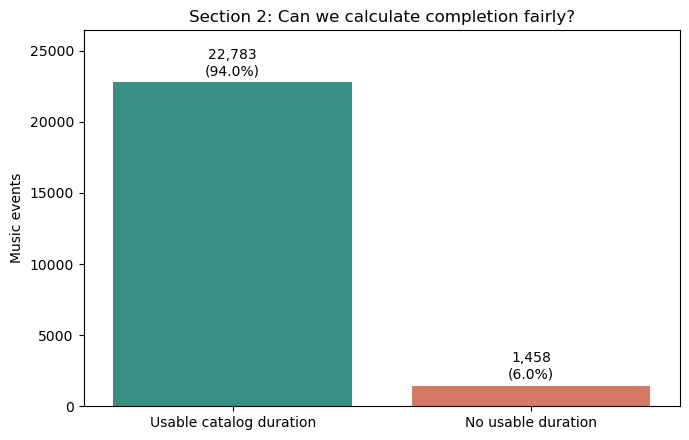

In [13]:
coverage_counts = pd.DataFrame(
    {
        "metadata status": ["Usable catalog duration", "No usable duration"],
        "events": [usable_duration_events, len(unique_music_rows) - usable_duration_events],
    }
)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    data=coverage_counts,
    x="metadata status",
    y="events",
    hue="metadata status",
    palette=["#2a9d8f", "#e76f51"],
    legend=False,
    ax=ax,
)
for bar, count in zip(ax.patches, coverage_counts["events"]):
    ax.annotate(
        f"{count:,}\n({count / len(unique_music_rows):.1%})",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
ax.set(
    title="Section 2: Can we calculate completion fairly?",
    xlabel="",
    ylabel="Music events",
    ylim=(0, coverage_counts["events"].max() * 1.16),
)
ax.title.set_y(1.05)
ax.ticklabel_format(axis="y", style="plain")
plt.tight_layout()
plt.show()

### Cell: inspect one joined event by hand

**What it does:** prints one raw music record beside the catalog values that were found for its track.

**How it does it:** it selects the first cleaned event, extracts its track ID, performs the same metadata lookup used later for every event, and prints relevant raw fields such as `ms_played`, `reason_start`, `reason_end`, and `shuffle`.

**Bigger picture:** this is a sanity check. Before turning thousands of rows into scores, it shows the actual ingredients and confirms that the join has the meaning we assume.

In [14]:
print("\nRepresentative enriched music event:")
example = unique_music_rows[0]
example_metadata = metadata_by_id.get(track_id_from_uri(example.get("spotify_track_uri")), {})
for key in (
    "ts", "spotify_track_uri", "master_metadata_track_name",
    "master_metadata_album_artist_name", "ms_played", "reason_start",
    "reason_end", "shuffle", "skipped",
):
    print(f"  {key}: {example.get(key)!r}")
print(f"  catalog duration (seconds): {example_metadata.get('duration_s')!r}")
print(f"  catalog genres: {example_metadata.get('genres')!r}")


Representative enriched music event:
  ts: '2022-12-27T11:53:56Z'
  spotify_track_uri: 'spotify:track:0AS63m1wHv9n4VVRizK6Hc'
  master_metadata_track_name: 'Mercy'
  master_metadata_album_artist_name: 'Shawn Mendes'
  ms_played: 8234
  reason_start: 'clickrow'
  reason_end: 'fwdbtn'
  shuffle: False
  skipped: True
  catalog duration (seconds): 208
  catalog genres: 'canadian pop, pop, viral pop'


### Cell: normalize names only as a fallback

**What it does:** defines a conservative backup identifier for tracks or artists that lack a Spotify ID, plus a helper for choosing a common display label later.

**How it does it:** `normalize_text` removes leading/trailing space, strips common `feat.` and `with` suffixes, decomposes accents, lowercases, and retains only letters and digits. `most_common_label` returns the most frequent label, breaking ties alphabetically.

**Bigger picture:** IDs remain the preferred identity. This fallback avoids treating harmless spelling differences such as `Beyonce` and `Beyoncé` as separate entities when IDs are absent.

In [15]:

def normalize_text(value):
    """Conservative fallback key for display-name variants."""
    text = (value or "").strip()
    text = text.split(" (feat.", 1)[0].split(" (with ", 1)[0]
    text = unicodedata.normalize("NFKD", text).lower()
    text = "".join(char for char in text if not unicodedata.combining(char))
    return "".join(char for char in text if char.isalnum())

def most_common_label(counter, fallback):
    if not counter:
        return fallback
    return sorted(counter.items(), key=lambda item: (-item[1], item[0]))[0][0]

### Cell: parse timestamps and order the history

**What it does:** converts Spotify timestamps into real datetime objects and sorts cleaned events from earliest to latest.

**How it does it:** Spotify's trailing `Z` means UTC; replacing it with `+00:00` lets `datetime.fromisoformat` create a timezone-aware timestamp. `sorted(..., key=...)` then orders all rows using that parsed time.

**Bigger picture:** session boundaries depend on the gap between adjacent events. That calculation is only meaningful after the listening history has been put in chronological order.

In [16]:
def parse_export_timestamp(value):
    return datetime.fromisoformat(str(value).replace("Z", "+00:00"))

ordered_rows = sorted(unique_music_rows, key=lambda row: parse_export_timestamp(row["ts"]))


### Cell: create one enriched `play` per listening event

**What it does:** walks through the ordered history, assigns a listening-session number, calculates completion when possible, and creates the `plays` list used by the model.

**How it does it:** it compares each timestamp with `previous_timestamp`; a gap greater than `session_gap_minutes * 60` increments `session_number`. For each row it joins duration and canonical artist data, calculates $\min(\text{ms played}/\text{duration ms}, 1)$, and stores both raw fields and derived fields in one dictionary. A Spotify ID is used as `track_key` or `artist_key` when available; normalized text is only a fallback.

**Bigger picture:** this is the bridge between messy export rows and model-ready events. It preserves the raw facts while adding comparable fields, but it does not yet decide which events count as a rejection.

In [17]:
plays = []
previous_timestamp = None
session_number = 0

for row in ordered_rows:
    timestamp = parse_export_timestamp(row["ts"])
    if (
        previous_timestamp is not None
        and (timestamp - previous_timestamp).total_seconds() > CONFIG["session_gap_minutes"] * 60
    ):
        session_number += 1
    previous_timestamp = timestamp

    track_id = track_id_from_uri(row.get("spotify_track_uri"))
    metadata = metadata_by_id.get(track_id)
    duration_s = metadata.get("duration_s") if metadata else None
    duration_ms = int(duration_s * 1000) if duration_s else None
    ms_played = int(row.get("ms_played") or 0)
    completion = min(ms_played / duration_ms, 1.0) if duration_ms else None
    reason_start = row.get("reason_start") or "unknown"
    reason_end = row.get("reason_end") or "unknown"
    export_artist = row.get("master_metadata_album_artist_name") or "Unknown artist"
    catalog_artist_id = metadata.get("catalog_artist_id") if metadata else None

    plays.append({
        "session": session_number,
        "timestamp": timestamp,
        "track_id": track_id,
        "track_key": track_id or f"text:{normalize_text(row.get('master_metadata_track_name'))}::{normalize_text(export_artist)}",
        "artist_key": f"id:{catalog_artist_id}" if catalog_artist_id else f"text:{normalize_text(export_artist)}",
        "track": row.get("master_metadata_track_name") or "Unknown track",
        "artist": export_artist,
        "catalog_artist": metadata.get("catalog_artist") if metadata else None,
        "duration_s": duration_s,
        "completion": completion,
        "ms_played": ms_played,
        "reason_start": reason_start,
        "reason_end": reason_end,
        "shuffle": bool(row.get("shuffle")),
        "chosen": reason_start in CONFIG["choice_starts"],
        "passively_served": reason_start in {"trackdone", "fwdbtn", "appload"},
        "genres": metadata.get("genres") if metadata else None,
        "popularity": metadata.get("popularity") if metadata else None,
        "release_year": metadata.get("release_year") if metadata else None,
        "energy": metadata.get("energy") if metadata else None,
        "valence": metadata.get("valence") if metadata else None,
    })

### Cell: put tracks into coarse duration bands

**What it does:** defines four duration categories: under two minutes, two to three-and-a-half, three-and-a-half to five, and five minutes or longer.

**How it does it:** an `if` chain returns the first matching label for `duration_s`. The thresholds are in seconds: 120, 210, and 300.

**Bigger picture:** a short track naturally reaches 30% sooner than a long track. Completion already adjusts for length, but these broad bands give the later contextual baseline another protection against comparing very different listening situations.

In [18]:
def duration_band(duration_s):
    if duration_s < 120:
        return "under-2m"
    if duration_s < 210:
        return "2m-to-3m30"
    if duration_s < 300:
        return "3m30-to-5m"
    return "5m-plus"

### Cell: assign context and behavioral labels

**What it does:** adds duration band, comparison context, `rapid_rejection`, and `durable_acceptance` to every enriched play.

**How it does it:** `start_bucket` groups related Spotify start reasons into plain labels. For events with a known duration, `context` combines start mechanism, shuffle status, and duration band. `rapid_rejection` is `True` only when three conditions hold: passive exposure, `reason_end == "fwdbtn"`, and completion no greater than 30%. `durable_acceptance` is `True` at 80% completion or above. Events without duration are deliberately marked ineligible.

**Bigger picture:** this is the notebook's definition of the evidence, not a statement of emotion. The later model compares rejection rates only within the same context and lets a near-complete listen counter a same-session skip loop.

In [19]:
def start_bucket(reason_start):
    if reason_start == "trackdone":
        return "continuation"
    if reason_start == "fwdbtn":
        return "skip-through"
    if reason_start == "appload":
        return "resume"
    return reason_start

for play in plays:
    if play["duration_s"]:
        play["duration_band"] = duration_band(play["duration_s"])
        play["context"] = (
            f"{start_bucket(play['reason_start'])}"
            f"|shuffle={int(play['shuffle'])}"
            f"|duration={play['duration_band']}"
        )
        play["rapid_rejection"] = (
            play["passively_served"]
            and play["reason_end"] == "fwdbtn"
            and play["completion"] <= CONFIG["rapid_completion"]
        )
        # A near-complete listen overrides a same-session skip loop as positive evidence.
        play["durable_acceptance"] = play["completion"] >= 0.80
    else:
        play["duration_band"] = None
        play["context"] = None
        play["rapid_rejection"] = False
        play["durable_acceptance"] = False


### Cell: report the prepared population

**What it does:** prints the number of de-duplicated events and the number of listening sessions found.

**How it does it:** `len(plays)` counts one prepared dictionary per cleaned event. `session_number` begins at zero, so adding one turns the final session index into a count.

**Bigger picture:** these are the denominators behind later results. The model will eventually collapse repeated events within each session, so knowing the starting number of events and sessions makes that reduction auditable.

In [20]:
print(f"Analysis events after deduplication: {len(plays):,}")
print(f"Listening sessions (>{CONFIG['session_gap_minutes']} min gap): {session_number + 1:,}")

Analysis events after deduplication: 24,241
Listening sessions (>30 min gap): 1,648


### Cell: isolate comparable plays and prepare percentiles

**What it does:** creates `metadata_plays`, the subset with known duration, collects their completion values, and defines a simple percentile helper.

**How it does it:** the list comprehension keeps only plays with `duration_s`. The second comprehension extracts `completion`, and `sorted` puts values in order. `percentile` turns a fraction such as `0.50` into a rounded list index; it returns `None` safely when there are no values.

**Bigger picture:** all completion summaries and rejection eligibility from here onward use only plays whose denominator is known. The percentile function gives an interpretable summary before the more detailed charts.

In [21]:
metadata_plays = [play for play in plays if play["duration_s"]]
completion_values = sorted(play["completion"] for play in metadata_plays)

def percentile(values, fraction):
    if not values:
        return None
    index = round((len(values) - 1) * fraction)
    return values[index]

### Cell: print completion coverage and typical values

**What it does:** reports how much of `plays` has a catalog duration and prints the 25th, 50th, and 75th percentiles of relative completion.

**How it does it:** it divides the `metadata_plays` count by all prepared events for coverage. The generator formats the three selected percentiles from `completion_values` as percentages, and `join` turns them into one readable line.

**Bigger picture:** this checks both data availability and normal listening behavior. It should be read before interpreting a threshold: the 30% cutoff has meaning only in relation to the observed completion distribution.

In [22]:
print(f"Events with catalog duration: {len(metadata_plays):,} / {len(plays):,} ({len(metadata_plays) / len(plays):.1%})")
print(
    "Completion fractions (duration-normalized): "
    + ", ".join(
        f"p{int(p * 100)}={percentile(completion_values, p):.0%}"
        for p in (0.25, 0.50, 0.75)
    )
)

Events with catalog duration: 22,783 / 24,241 (94.0%)
Completion fractions (duration-normalized): p25=28%, p50=100%, p75=100%


### Cell: chart completion thresholds and playback starts

**What it does:** produces two complementary diagnostics: a histogram of normalized completion and a count of each Spotify start reason.

**How it does it:** it turns each completion fraction into percent for the histogram, then draws vertical lines at 30% and 80%. Separately, `Counter` totals `reason_start` values and converts those totals into a small table for the horizontal bar chart.

**Bigger picture:** the histogram shows that “early” must be defined relative to full track length. The start-reason chart shows why the model excludes deliberate starts: it is trying to measure rejection of passive exposure, not regret after choosing a song.

The dashed lines represent intentionally different ideas:

- **30%** is the maximum completion allowed for a rapid rejection, after the passive-start and forward-skip conditions are also satisfied.
- **80%** is durable acceptance, which later overrides a same-session skip loop as positive evidence.

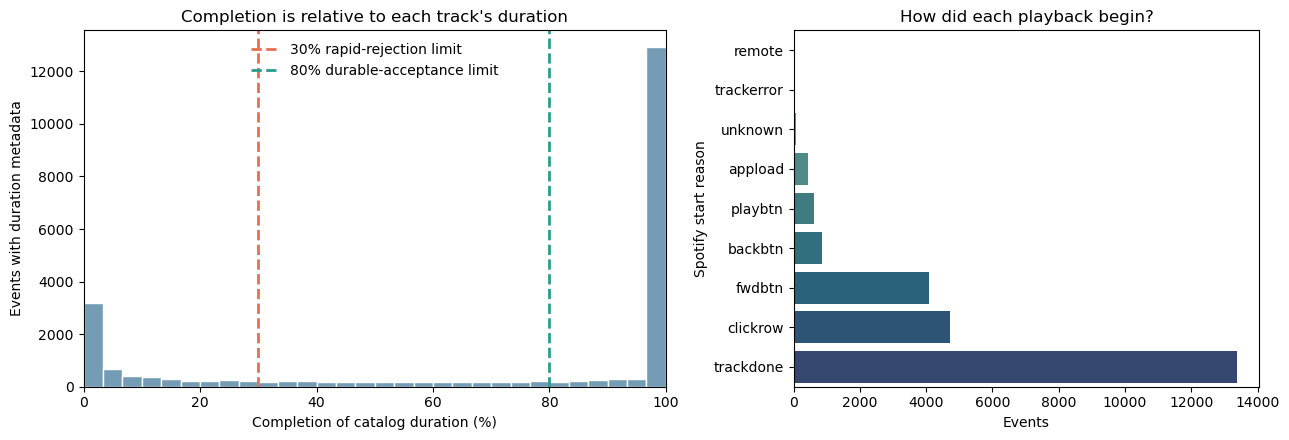

In [23]:
completion_frame = pd.DataFrame({"completion_percent": [value * 100 for value in completion_values]})
start_counts = (
    pd.Series(Counter(play["reason_start"] for play in plays), name="events")
    .rename_axis("reason_start")
    .reset_index()
    .sort_values("events", ascending=True)
)

fig, (completion_ax, start_ax) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.25, 1]})
sns.histplot(
    data=completion_frame,
    x="completion_percent",
    bins=30,
    color="#457b9d",
    edgecolor="white",
    ax=completion_ax,
)
completion_ax.axvline(30, color="#e76f51", linestyle="--", linewidth=2, label="30% rapid-rejection limit")
completion_ax.axvline(80, color="#2a9d8f", linestyle="--", linewidth=2, label="80% durable-acceptance limit")
completion_ax.set(
    title="Completion is relative to each track's duration",
    xlabel="Completion of catalog duration (%)",
    ylabel="Events with duration metadata",
    xlim=(0, 100),
)
completion_ax.legend(frameon=False, loc="upper center")

sns.barplot(
    data=start_counts,
    x="events",
    y="reason_start",
    hue="reason_start",
    palette="crest",
    legend=False,
    ax=start_ax,
)
start_ax.set(
    title="How did each playback begin?",
    xlabel="Events",
    ylabel="Spotify start reason",
)
start_ax.ticklabel_format(axis="x", style="plain")
plt.tight_layout()
plt.show()

### Cell: draw your completion-density view

**What it does:** draws a KDE curve, a smoothed estimate of where completion values are concentrated.

**How it does it:** Seaborn's `kdeplot` takes the sorted `completion_values` list and estimates a continuous density curve instead of grouping values into bars.

**Bigger picture:** this is another way to inspect the same relative-completion evidence. Unlike the histogram, it emphasizes the overall shape; it does not change labels or affect the ranking.

<Axes: ylabel='Density'>

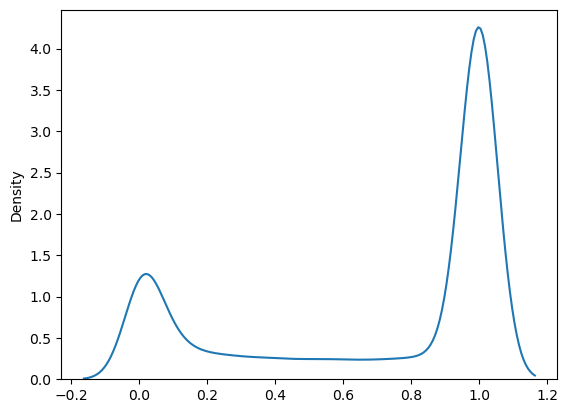

In [24]:
import seaborn as sns

sns.kdeplot(completion_values)

### Cell: print start-reason frequencies

**What it does:** prints how many events began for each Spotify `reason_start` value.

**How it does it:** `Counter` counts the value from every prepared play, and `most_common()` returns the results from largest to smallest. The format specification aligns the output into readable columns.

**Bigger picture:** the preceding chart summarizes these same counts visually. This table preserves the exact labels and values, which is useful when checking which starts are deliberate choices and which can qualify as passive exposure.

In [25]:
print("\nStart reasons:")
for value, count in Counter(play["reason_start"] for play in plays).most_common():
    print(f"  {value:>12}: {count:>6,}")


Start reasons:
     trackdone: 13,386
      clickrow:  4,727
        fwdbtn:  4,090
       backbtn:    865
       playbtn:    625
       appload:    424
       unknown:     61
    trackerror:     42
        remote:     21


### Cell: print end-reason frequencies

**What it does:** prints the distribution of Spotify `reason_end` values.

**How it does it:** it repeats the `Counter(...).most_common()` pattern, this time reading `reason_end` from every prepared play. The wider alignment is only for longer reason names.

**Bigger picture:** `fwdbtn` is central to the rejection definition because it records an explicit forward action. This audit shows how common it is relative to natural endings such as `trackdone` and other ways playback can stop.

In [26]:
print("\nEnd reasons:")
for value, count in Counter(play["reason_end"] for play in plays).most_common():
    print(f"  {value:>32}: {count:>6,}")


End reasons:
                         trackdone: 13,420
                           endplay:  4,453
                            fwdbtn:  4,043
                           backbtn:    859
                            logout:    708
      unexpected-exit-while-paused:    542
                   unexpected-exit:    194
                            remote:     17
                        trackerror:      5


### Cell: quantify deliberate selections

**What it does:** counts metadata-eligible events that began with `clickrow` or `playbtn`.

**How it does it:** `play['chosen']` was created earlier from `CONFIG['choice_starts']`. Python treats `True` as one and `False` as zero, so summing the boolean values counts deliberately chosen plays; the same sum divided by `len(metadata_plays)` gives the percentage.

**Bigger picture:** deliberate choice is counterevidence to a simple “Spotify served this and I rejected it” story. The model does not turn chosen starts into negative trials.

In [27]:
print(
    "\nDirectly chosen events (clickrow/playbtn): "
    f"{sum(play['chosen'] for play in metadata_plays):,} / {len(metadata_plays):,} ({sum(play['chosen'] for play in metadata_plays) / len(metadata_plays):.2%})"
)


Directly chosen events (clickrow/playbtn): 5,011 / 22,783 (21.99%)


### Cell: count raw rapid-rejection events

**What it does:** reports the number and percentage of metadata-eligible events currently labelled `rapid_rejection`.

**How it does it:** it sums the boolean `rapid_rejection` field created earlier and divides by all `metadata_plays`. The filtered generator in the numerator is redundant but still counts only `True` labels.

**Bigger picture:** this is deliberately a *before session collapsing* count. It is not yet the number of independent negative trials, because one frustrating sequence can contain several skip events; the later model reduces those within-session repeats.

In [28]:
print(
    "Passively served rapid rejections before session collapsing: "
    f"{sum(play['rapid_rejection'] for play in metadata_plays):,} ({sum(play['rapid_rejection'] for play in metadata_plays if play['rapid_rejection']) / len(metadata_plays):.2%})"
)

Passively served rapid rejections before session collapsing: 2,251 (9.88%)


### Cell: show why a fixed 30-second rule would fail

**What it does:** counts plays shorter than 30 seconds that nevertheless exceed the model's 30% completion threshold.

**How it does it:** it tests two conditions at once: `ms_played <= 30_000` and `completion > rapid_completion`. The count represents short absolute listens that were relatively substantial for their track length.

**Bigger picture:** this is the concrete argument for using a percentage of catalog duration rather than a flat number of seconds. A fixed 30-second rule would wrongly treat these events as early rejections.

In [29]:
print(
    "Why duration matters: "
    f"{sum(play['ms_played'] <= 30_000 and play['completion'] > CONFIG['rapid_completion'] for play in metadata_plays):,} "
    "events are under 30 seconds but exceed the relative rejection threshold."
)
# print those events that are under 30 seconds but exceed the relative rejection threshold


Why duration matters: 4 events are under 30 seconds but exceed the relative rejection threshold.


### Cell: compare track duration with completion

**What it does:** plots one point per metadata-eligible play, with catalog duration on the x-axis and relative completion on the y-axis, then fits a straight trend line.

**How it does it:** `DataFrame(metadata_plays)` turns the prepared dictionaries into columns. `sns.lmplot` draws the scatter and an ordinary least-squares line; the red `line_kws` setting only changes its color.

**Bigger picture:** this is exploratory, not a scoring rule. It helps you see whether completion varies systematically with track length and supports the decision to compare relative completion rather than raw milliseconds.

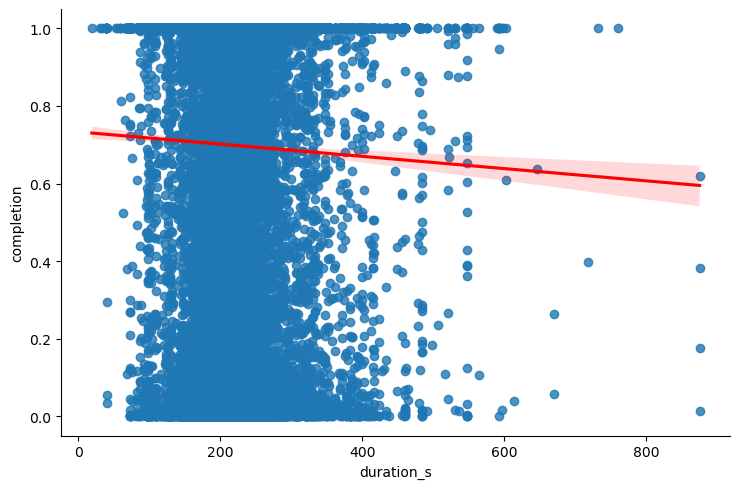

In [30]:
import pandas as pd
import seaborn as sns
df_metadata = pd.DataFrame(metadata_plays)
sns.lmplot(x='duration_s', y='completion', fit_reg=True, data=df_metadata, aspect=1.5, line_kws={'color': 'red'})

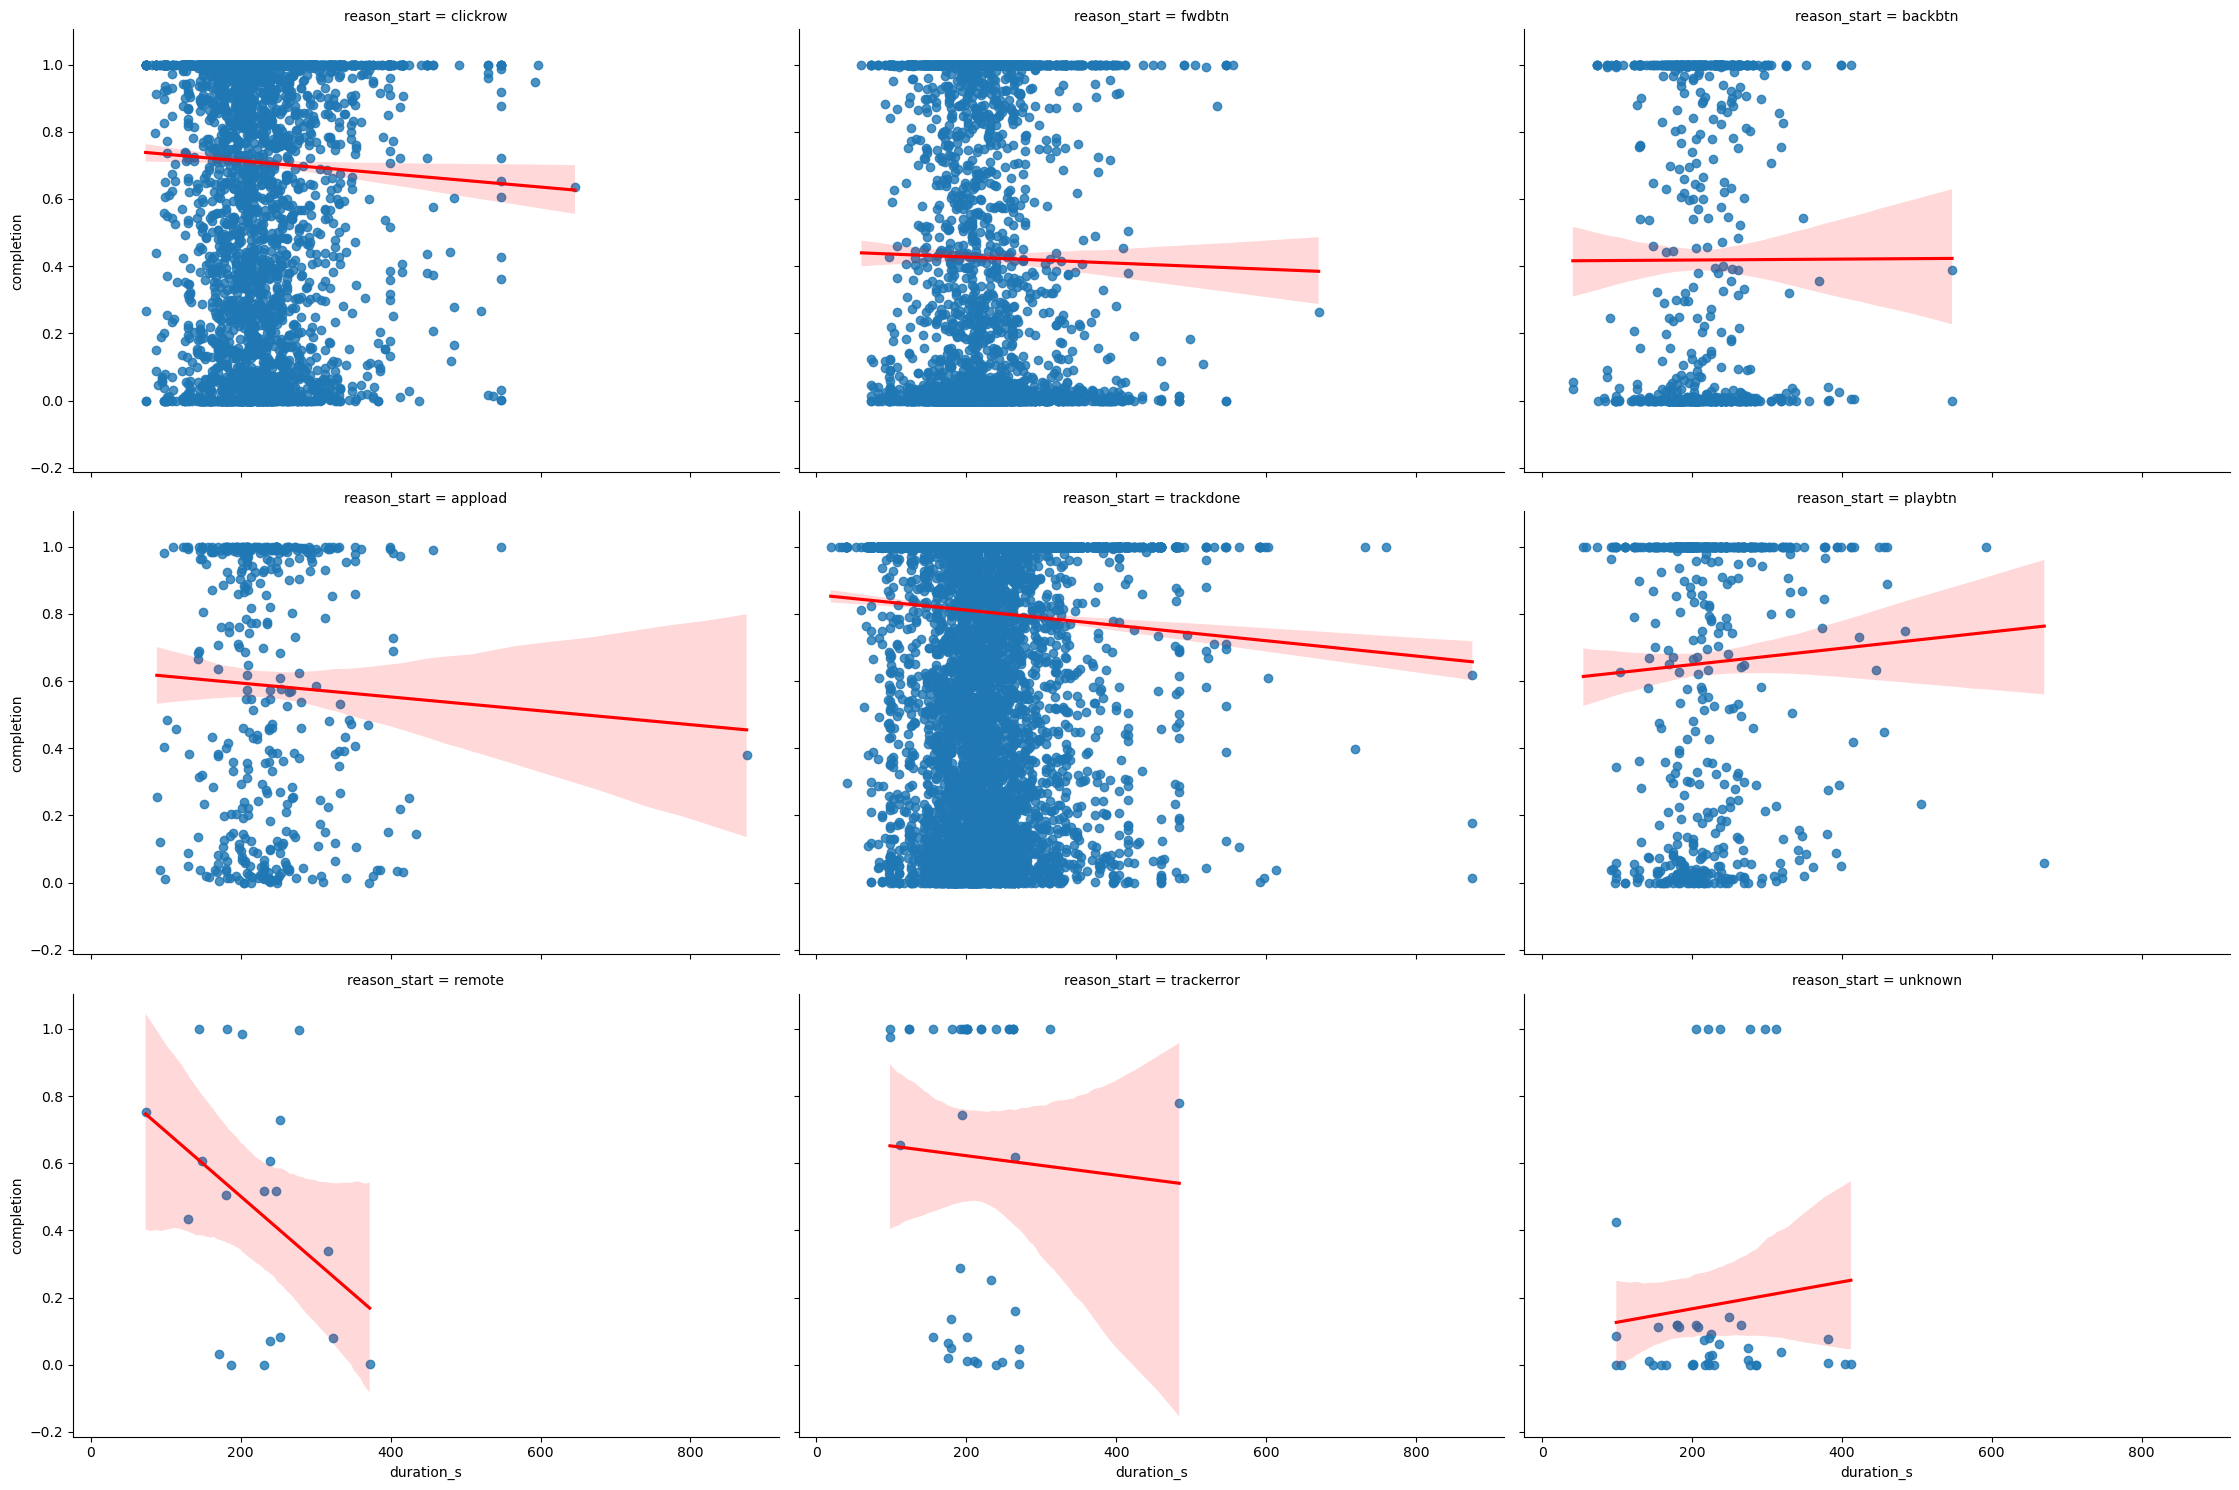

In [ ]:
# Scatter plot of completion vs duration, faceted by reason_start with regression line
sns.lmplot(
    x='duration_s', y='completion', fit_reg=True,
    data=df_metadata, aspect=1.5,
    line_kws={'color': 'red'},
    col='reason_start',
    col_wrap=3,
    facet_kws={'sharex': True, 'sharey': True}
)

In [32]:
df_metadata

,session,timestamp,track_id,track_key,artist_key,track,artist,catalog_artist,duration_s,completion,...,passively_served,genres,popularity,release_year,energy,valence,duration_band,context,rapid_rejection,durable_acceptance
0,0,2022-12-27 11:53:56+00:00,0AS63m1wHv9n4VVRizK6Hc,0AS63m1wHv9n4VVRizK6Hc,id:7n2wHs1TKAczGzO7Dd2rGr,Mercy,Shawn Mendes,Shawn Mendes,208,0.039587,...,False,"canadian pop, pop, viral pop",0.81,2017,0.662,0.338,2m-to-3m30,clickrow|shuffle=0|duration=2m-to-3m30,False,False
1,0,2022-12-27 11:53:57+00:00,7fRruZ12gXGwBs0zXQ6e5V,7fRruZ12gXGwBs0zXQ6e5V,id:06HL4z0CvFAxyc27GXpf02,Babe,Sugarland,Taylor Swift,215,0.004521,...,True,pop,0.53,2018,0.777,0.664,3m30-to-5m,skip-through|shuffle=0|duration=3m30-to-5m,False,False
2,1,2022-12-27 12:27:02+00:00,0AS63m1wHv9n4VVRizK6Hc,0AS63m1wHv9n4VVRizK6Hc,id:7n2wHs1TKAczGzO7Dd2rGr,Mercy,Shawn Mendes,Shawn Mendes,208,0.570288,...,False,"canadian pop, pop, viral pop",0.81,2017,0.662,0.338,2m-to-3m30,backbtn|shuffle=0|duration=2m-to-3m30,False,False
3,2,2022-12-27 18:25:18+00:00,0AS63m1wHv9n4VVRizK6Hc,0AS63m1wHv9n4VVRizK6Hc,id:7n2wHs1TKAczGzO7Dd2rGr,Mercy,Shawn Mendes,Shawn Mendes,208,1.000000,...,True,"canadian pop, pop, viral pop",0.81,2017,0.662,0.338,2m-to-3m30,resume|shuffle=0|duration=2m-to-3m30,False,True
4,2,2022-12-27 18:26:12+00:00,7fRruZ12gXGwBs0zXQ6e5V,7fRruZ12gXGwBs0zXQ6e5V,id:06HL4z0CvFAxyc27GXpf02,Babe,Sugarland,Taylor Swift,215,0.248167,...,True,pop,0.53,2018,0.777,0.664,3m30-to-5m,continuation|shuffle=0|duration=3m30-to-5m,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22778,1647,2026-09-04 20:32:50+00:00,0T5iIrXA4p5GsubkhuBIKV,0T5iIrXA4p5GsubkhuBIKV,id:5XKFrudbV4IiuE5WuTPRmT,Until I Found You,Stephen Sanchez,Stephen Sanchez,177,0.325864,...,False,gen z singer-songwriter,0.79,2021,0.508,0.227,2m-to-3m30,playbtn|shuffle=1|duration=2m-to-3m30,False,False
22779,1647,2026-09-04 20:36:16+00:00,69vToJ9BMbbLlFZo7k7A7B,69vToJ9BMbbLlFZo7k7A7B,id:6ydoSd3N2mwgwBHtF6K7eX,You Are The Reason,Calum Scott,Calum Scott,204,1.000000,...,False,pop,0.78,2018,0.235,0.220,2m-to-3m30,playbtn|shuffle=1|duration=2m-to-3m30,False,True
22780,1647,2026-09-04 20:36:24+00:00,2BOqDYLOJBiMOXShCV1neZ,2BOqDYLOJBiMOXShCV1neZ,id:6ydoSd3N2mwgwBHtF6K7eX,Dancing On My Own,Calum Scott,Calum Scott,260,0.025719,...,True,pop,0.80,2018,0.174,0.231,3m30-to-5m,continuation|shuffle=1|duration=3m30-to-5m,False,False
22781,1647,2026-09-04 20:39:14+00:00,4Fuf1v4kPQ6RIvEGlUfvaq,4Fuf1v4kPQ6RIvEGlUfvaq,id:3OEJ7D4RwbnNFuG9JczKEa,Grey,Yung Filly,Yung Filly,169,1.000000,...,False,"london rap, uk hip hop",0.63,2024,0.836,0.891,2m-to-3m30,playbtn|shuffle=1|duration=2m-to-3m30,False,True


## 4. Convert Events into Independent Exposure Trials

A Spotify export logs events, not independent opinions. One accidental autoplay loop can therefore create dozens of forward-skip events in a single sitting.

For the primary model, one **track-session** is one trial:

- The track must have catalog duration metadata.
- Any directly chosen start (`clickrow` or `playbtn`) removes that track-session from passive-exposure scoring.
- A trial is a **rejection** only if a passive play ends in an explicit forward skip before 30% completion, with no later durable listen in that same session.
- A trial is an **acceptance** if the listener reaches at least 80% completion in that session.
- All other partial or interrupted events are deliberately left unlabeled.

This is conservative on purpose: it tries to identify recurring, unprompted rejection rather than ordinary listening noise.

In [33]:
def make_session_trials(grouped_events):
    """Collapse all events for one entity in one listening session into one outcome."""
    trials = []
    seen_sessions = Counter()
    chosen_sessions = Counter()

    for (session, entity_key), events in grouped_events.items():
        seen_sessions[entity_key] += 1
        if any(event["chosen"] for event in events):
            # An intentional start anywhere in this entity-session is counterevidence.
            chosen_sessions[entity_key] += 1
            continue

        passive_events = [event for event in events if event["passively_served"]]
        durable_events = [event for event in passive_events if event["durable_acceptance"]]
        rejection_events = [event for event in passive_events if event["rapid_rejection"]]

        if durable_events:
            label = 0
            anchor = max(durable_events, key=lambda event: (event["completion"], event["timestamp"]))
        elif rejection_events:
            label = 1
            anchor = min(rejection_events, key=lambda event: event["timestamp"])
        else:
            continue

        trial = dict(anchor)
        trial["entity_key"] = entity_key
        trial["label"] = label
        trial["event_count"] = len(events)
        trials.append(trial)

    return trials, seen_sessions, chosen_sessions

In [34]:
track_session_events = defaultdict(list)
artist_session_events = defaultdict(list)
for play in metadata_plays:
    track_session_events[(play["session"], play["track_key"])].append(play)
    artist_session_events[(play["session"], play["artist_key"])].append(play)

In [35]:
track_trials, track_seen_sessions, track_chosen_sessions = make_session_trials(track_session_events)
artist_trials, artist_seen_sessions, artist_chosen_sessions = make_session_trials(artist_session_events)

assert len({(trial["session"], trial["entity_key"]) for trial in track_trials}) == len(track_trials)
assert len({(trial["session"], trial["entity_key"]) for trial in artist_trials}) == len(artist_trials)
assert {trial["label"] for trial in track_trials}.issubset({0, 1})
assert {trial["label"] for trial in artist_trials}.issubset({0, 1})


In [36]:
rejected_track_keys_by_artist = defaultdict(set)
for trial in track_trials:
    if trial["label"]:
        rejected_track_keys_by_artist[trial["artist_key"]].add(trial["track_key"])

print("Track-level independent trials:")
print(f"  Track-session groups: {len(track_session_events):,}")
print(f"  Groups excluded by a direct start: {sum(track_chosen_sessions.values()):,}")
print(f"  Labeled trials: {len(track_trials):,}")
print(f"  Rejections: {sum(trial['label'] for trial in track_trials):,}")
print(f"  Acceptances: {sum(not trial['label'] for trial in track_trials):,}")
print("\nArtist-level independent trials:")
print(f"  Artist-session groups: {len(artist_session_events):,}")
print(f"  Groups excluded by a direct start: {sum(artist_chosen_sessions.values()):,}")
print(f"  Labeled trials: {len(artist_trials):,}")
print(f"  Rejections: {sum(trial['label'] for trial in artist_trials):,}")
print(f"  Acceptances: {sum(not trial['label'] for trial in artist_trials):,}")
print(
    "\nEvent-to-session reduction: "
    f"{sum(play['rapid_rejection'] for play in metadata_plays):,} rapid events -> "
    f"{sum(trial['label'] for trial in track_trials):,} independent track-session rejections"
)

Track-level independent trials:
  Track-session groups: 19,514
  Groups excluded by a direct start: 4,478
  Labeled trials: 11,984
  Rejections: 2,026
  Acceptances: 9,958

Artist-level independent trials:
  Artist-session groups: 12,929
  Groups excluded by a direct start: 3,564
  Labeled trials: 7,570
  Rejections: 1,258
  Acceptances: 6,312

Event-to-session reduction: 2,251 rapid events -> 2,026 independent track-session rejections


## 5. Primary Model: Contextual Excess Rejection

For every independent trial, the model estimates how often a comparable passive play is rejected. Comparability is defined by:

- how the track started: continuation, skip-through, or app resume;
- whether shuffle was on; and
- a catalog-duration band, so a 90-second track is not judged against an 8-minute track.

For an entity $e$ in context $c$, the baseline is a leave-one-entity-out smoothed rejection rate:

$$
q_{e,c} = \frac{r_{-e,c} + s\,\bar r}{n_{-e,c} + s}
$$

where $r_{-e,c}$ and $n_{-e,c}$ exclude the entity being evaluated, $\bar r$ is the overall trial rejection rate, and $s=20$ provides light stabilization for sparse contexts.

The central signal is its excess rejection rate:

$$
\operatorname{excess}(e) = \frac{\sum_i(y_i-q_{e,c_i})}{n_e}
$$

A one-sided normal-tail screen and Benjamini-Hochberg false-discovery adjustment flag signals unlikely to be ordinary context noise. The final ranking multiplies positive contextual excess by $1-\text{direct-choice rate}$: a song or artist repeatedly selected on purpose is counterevidence against a blanket “hated” interpretation.

Metadata is used directly for duration normalization and to describe/audit finalists. Genre, popularity, and audio descriptors are **not** treated as causes of dislike.

In [37]:
def normal_survival(z_value):
    """One-sided standard-normal tail probability without extra dependencies."""
    return 0.5 * erfc(z_value / sqrt(2))


def benjamini_hochberg(rows):
    """Attach monotone Benjamini-Hochberg q-values to score rows in place."""
    ordered = sorted(enumerate(rows), key=lambda item: item[1]["p_value"])
    total = len(ordered)
    smallest_future_q = 1.0
    for rank, (index, row) in reversed(list(enumerate(ordered, start=1))):
        adjusted = min(smallest_future_q, row["p_value"] * total / rank, 1.0)
        rows[index]["q_value"] = adjusted
        smallest_future_q = adjusted


def score_contextual_rejection(trials, seen_sessions, chosen_sessions):
    """Score entities against their own leave-one-entity-out context baseline."""
    global_rejection_rate = sum(trial["label"] for trial in trials) / len(trials)
    context_n = Counter(trial["context"] for trial in trials)
    context_r = Counter(
        trial["context"] for trial in trials if trial["label"]
    )
    entity_context_n = defaultdict(Counter)
    entity_context_r = defaultdict(Counter)
    entity_n = Counter()
    entity_r = Counter()
    display_names = defaultdict(Counter)
    display_artists = defaultdict(Counter)

    for trial in trials:
        key = trial["entity_key"]
        context = trial["context"]
        entity_context_n[key][context] += 1
        entity_context_r[key][context] += trial["label"]
        entity_n[key] += 1
        entity_r[key] += trial["label"]
        display_names[key][trial["track"] if trial["track_key"] == key else (trial["catalog_artist"] or trial["artist"])] += 1
        display_artists[key][trial["artist"]] += 1

    scored = []
    for key, n_trials in entity_n.items():
        expected_rejections = 0.0
        null_variance = 0.0
        for context, own_n in entity_context_n[key].items():
            other_n = context_n[context] - own_n
            other_r = context_r[context] - entity_context_r[key][context]
            baseline = (
                other_r + CONFIG["prior_strength"] * global_rejection_rate
            ) / (other_n + CONFIG["prior_strength"])
            expected_rejections += own_n * baseline
            null_variance += own_n * baseline * (1.0 - baseline)

        rejections = entity_r[key]
        excess = (rejections - expected_rejections) / n_trials
        z_value = (rejections - expected_rejections) / sqrt(null_variance) if null_variance else 0.0
        p_value = normal_survival(z_value) if z_value > 0 else 1.0
        choice_rate = chosen_sessions[key] / seen_sessions[key] if seen_sessions[key] else 0.0
        scored.append({
            "key": key,
            "name": most_common_label(display_names[key], "Unknown"),
            "artist": most_common_label(display_artists[key], "Unknown"),
            "trials": n_trials,
            "rejections": rejections,
            "observed_rate": rejections / n_trials,
            "baseline_rate": expected_rejections / n_trials,
            "excess_rate": excess,
            "z_value": z_value,
            "p_value": p_value,
            "choice_rate": choice_rate,
            "score": max(excess, 0.0) * (1.0 - choice_rate),
        })

    benjamini_hochberg(scored)
    return scored, global_rejection_rate


def rank_candidates(rows, *, entity):
    if entity == "track":
        min_trials = CONFIG["track_min_exposures"]
        min_rejections = CONFIG["track_min_rejections"]
        min_excess = CONFIG["track_min_excess_rate"]
    else:
        min_trials = CONFIG["artist_min_exposures"]
        min_rejections = CONFIG["artist_min_rejections"]
        min_excess = CONFIG["artist_min_excess_rate"]

    candidates = []
    for row in rows:
        row["qualifies"] = (
            row["trials"] >= min_trials
            and row["rejections"] >= min_rejections
            and row["excess_rate"] >= min_excess
            and row["q_value"] <= CONFIG["max_false_discovery_rate"]
        )
        candidates.append(row)

    return sorted(
        (row for row in candidates if row["qualifies"]),
        key=lambda row: (-row["score"], -row["z_value"], -row["trials"], row["name"]),
    )


def print_candidates(title, rows, include_breadth=False, limit=10):
    print(f"\n{title}")
    if not rows:
        print("  No entity meets the predeclared support, excess, and FDR thresholds.")
        return
    header = "  #  Name / artist                              score   rejected / trials  excess  choice  q"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for rank, row in enumerate(rows[:limit], start=1):
        name = row["name"] if not row["artist"] or row["name"] == row["artist"] else f"{row['name']} - {row['artist']}"
        suffix = f"  tracks={row['rejected_tracks']}" if include_breadth else ""
        print(
            f"  {rank:>2}  {name[:42]:<42} "
            f"{row['score']:>6.1%}  {row['rejections']:>3}/{row['trials']:<3} "
            f"{row['excess_rate']:>7.1%} {row['choice_rate']:>6.1%} {row['q_value']:.3g}{suffix}"
        )


track_scores, global_track_rejection_rate = score_contextual_rejection(
    track_trials, track_seen_sessions, track_chosen_sessions
)
artist_scores, global_artist_rejection_rate = score_contextual_rejection(
    artist_trials, artist_seen_sessions, artist_chosen_sessions
)

for row in artist_scores:
    row["rejected_tracks"] = len(rejected_track_keys_by_artist.get(row["key"], set()))
artist_candidates_before_breadth = rank_candidates(artist_scores, entity="artist")
artist_candidates = [
    row for row in artist_candidates_before_breadth
    if row["rejected_tracks"] >= CONFIG["artist_min_tracks"]
]
track_candidates = rank_candidates(track_scores, entity="track")

print(f"Global track-session rejection rate: {global_track_rejection_rate:.1%}")
print(f"Global artist-session rejection rate: {global_artist_rejection_rate:.1%}")
print(f"Track hypotheses screened: {len(track_scores):,}")
print(f"Artist hypotheses screened: {len(artist_scores):,}")
print_candidates("Qualified track candidates", track_candidates)
print_candidates(
    "Qualified multi-track artist candidates",
    artist_candidates,
    include_breadth=True,
)

if artist_candidates_before_breadth and not artist_candidates:
    strongest = artist_candidates_before_breadth[0]
    print(
        "\nArtist verdict withheld: the strongest artist-associated signal is "
        f"{strongest['name']}, but it only spans {strongest['rejected_tracks']} rejected track(s)."
    )

Global track-session rejection rate: 16.9%
Global artist-session rejection rate: 16.6%
Track hypotheses screened: 2,615
Artist hypotheses screened: 707

Qualified track candidates
  #  Name / artist                              score   rejected / trials  excess  choice  q
  ------------------------------------------------------------------------------------------
   1  No Guidance (feat. Drake) - Chris Brown     37.2%    6/10    40.4%   7.7% 0.00355
   2  Laugh Now Cry Later (feat. Lil Durk) - Dra  32.5%   13/22    36.1%  10.0% 9.9e-05
   3  If You Want Love - NF                       30.5%    7/12    40.6%  25.0% 0.000837
   4  Bloom - Aqyila                              24.3%   11/20    33.2%  26.7% 0.00119
   5  p r i d e . i s . t h e . d e v i l (with   24.1%   14/29    26.3%   8.3% 0.00193
   6  m y . l i f e (with 21 Savage & Morray) -   24.1%    7/13    29.5%  18.2% 0.0472
   7  WAIT FOR U (feat. Drake & Tems) - Future    24.1%    6/15    32.5%  25.9% 2.23e-05
   8  The Night W

## 6. Artist Model: Pool Track-Level Evidence, Then Require Breadth

The artist-session version above is intentionally strict, but it can be too blunt: completing one song by an artist in a session should not erase a rapid rejection of a different song by that artist.

The artist model therefore reuses the independent **track-session** trials, pools their contextual evidence by artist, and excludes the whole artist from each matched baseline. It still uses direct artist-session starts as counterevidence and adds a breadth requirement: at least two distinct tracks must produce a rejection. The earlier artist-session result is retained as a conservative cross-check.

In [38]:
artist_track_trials = []
for trial in track_trials:
    pooled_trial = dict(trial)
    pooled_trial["entity_key"] = trial["artist_key"]
    artist_track_trials.append(pooled_trial)

artist_pooled_scores, global_artist_pooled_rejection_rate = score_contextual_rejection(
    artist_track_trials,
    artist_seen_sessions,
    artist_chosen_sessions,
)
for row in artist_pooled_scores:
    row["rejected_tracks"] = len(rejected_track_keys_by_artist.get(row["key"], set()))

artist_pooled_candidates_before_breadth = rank_candidates(artist_pooled_scores, entity="artist")
artist_pooled_candidates = [
    row for row in artist_pooled_candidates_before_breadth
    if row["rejected_tracks"] >= CONFIG["artist_min_tracks"]
]

print(f"Pooled track-session artist rejection rate: {global_artist_pooled_rejection_rate:.1%}")
print_candidates(
    "Qualified multi-track artist candidates (pooled track-session evidence)",
    artist_pooled_candidates,
    include_breadth=True,
)

if artist_pooled_candidates_before_breadth and not artist_pooled_candidates:
    strongest = artist_pooled_candidates_before_breadth[0]
    print(
        "\nArtist verdict withheld: the strongest pooled signal is "
        f"{strongest['name']}, but it only spans {strongest['rejected_tracks']} rejected track(s)."
    )

Pooled track-session artist rejection rate: 16.9%

Qualified multi-track artist candidates (pooled track-session evidence)
  #  Name / artist                              score   rejected / trials  excess  choice  q
  ------------------------------------------------------------------------------------------
   1  Eyob Mekonen                                30.8%   23/39    33.2%   7.4% 4.9e-06  tracks=12
   2  21 Savage                                   16.6%   19/45    20.6%  19.0% 0.00202  tracks=6


## 7. Robustness Checks

The 30% threshold is a transparent modeling choice, not a fact of nature. The notebook checks whether the leading candidates remain leading when “rapid” is defined as a forward skip before 20%, 25%, 30%, 35%, or 40% completion.

It then bootstraps whole listening sessions. Resampling by session preserves within-sitting dependence, including skip-through behavior and direct choices. A result is only called stable when it wins a substantial share of bootstrap reruns.

In [39]:
def track_trials_at_threshold(rejection_completion):
    """Rebuild labels at a new duration-normalized rejection cutoff."""
    original_labels = [play["rapid_rejection"] for play in metadata_plays]
    try:
        for play in metadata_plays:
            play["rapid_rejection"] = (
                play["passively_served"]
                and play["reason_end"] == "fwdbtn"
                and play["completion"] <= rejection_completion
            )
        return make_session_trials(track_session_events)
    finally:
        for play, label in zip(metadata_plays, original_labels):
            play["rapid_rejection"] = label


def pooled_artist_candidates(track_trial_set, artist_seen, artist_chosen):
    pooled_trials = []
    rejected_tracks = defaultdict(set)
    for trial in track_trial_set:
        pooled = dict(trial)
        pooled["entity_key"] = trial["artist_key"]
        pooled_trials.append(pooled)
        if trial["label"]:
            rejected_tracks[trial["artist_key"]].add(trial["track_key"])

    scores, _ = score_contextual_rejection(pooled_trials, artist_seen, artist_chosen)
    for row in scores:
        row["rejected_tracks"] = len(rejected_tracks[row["key"]])
    qualified = rank_candidates(scores, entity="artist")
    return [row for row in qualified if row["rejected_tracks"] >= CONFIG["artist_min_tracks"]]


threshold_results = []
for threshold in (0.20, 0.25, 0.30, 0.35, 0.40):
    threshold_track_trials, threshold_seen, threshold_chosen = track_trials_at_threshold(threshold)
    threshold_track_scores, _ = score_contextual_rejection(
        threshold_track_trials, threshold_seen, threshold_chosen
    )
    threshold_track_candidates = rank_candidates(threshold_track_scores, entity="track")
    threshold_artist_candidates = pooled_artist_candidates(
        threshold_track_trials, artist_seen_sessions, artist_chosen_sessions
    )
    threshold_results.append({
        "threshold": threshold,
        "track": threshold_track_candidates[0] if threshold_track_candidates else None,
        "artist": threshold_artist_candidates[0] if threshold_artist_candidates else None,
    })

print("Sensitivity to the definition of an early rejection:")
print("  cutoff   top qualified track                         top qualified multi-track artist")
print("  " + "-" * 86)
for result in threshold_results:
    track = result["track"]
    artist = result["artist"]
    track_label = f"{track['name']} - {track['artist']}" if track else "no qualified result"
    artist_label = artist["name"] if artist else "no qualified result"
    print(f"  {result['threshold']:>5.0%}   {track_label[:43]:<43} {artist_label[:35]}")

stable_track_thresholds = Counter(
    result["track"]["key"] for result in threshold_results if result["track"]
)
stable_artist_thresholds = Counter(
    result["artist"]["key"] for result in threshold_results if result["artist"]
)
print("\nThreshold wins:")
print("  Tracks: " + ", ".join(f"{key}: {count}/5" for key, count in stable_track_thresholds.most_common(3)))
print("  Artists: " + ", ".join(f"{key}: {count}/5" for key, count in stable_artist_thresholds.most_common(3)))

Sensitivity to the definition of an early rejection:
  cutoff   top qualified track                         top qualified multi-track artist
  --------------------------------------------------------------------------------------
    20%   Laugh Now Cry Later (feat. Lil Durk) - Drak Eyob Mekonen
    25%   If You Want Love - NF                       Eyob Mekonen
    30%   No Guidance (feat. Drake) - Chris Brown     Eyob Mekonen
    35%   No Guidance (feat. Drake) - Chris Brown     Eyob Mekonen
    40%   LET GO - Central Cee                        Eyob Mekonen

Threshold wins:
  Tracks: 6XHVuErjQ4XNm6nDPVCxVX: 2/5, 2SAqBLGA283SUiwJ3xOUVI: 1/5, 3i5qVV8azKqGFK4Gzdt5YS: 1/5
  Artists: id:5hn5axBeYPCxuGA07FE731: 5/5


### Session Bootstrap

A bootstrap resamples the 1,095 complete listening sessions with replacement 250 times. Each resample rebuilds the trials and reruns the same score, support, false-discovery, direct-choice, and multi-track rules.

The bootstrap reports the share of reruns won by each candidate. This is not a literal probability that somebody hates a song; it is a stability check for the **ranking procedure** under plausible reweightings of the listener’s sessions.

In [40]:
session_events = defaultdict(list)
for play in metadata_plays:
    session_events[play["session"]].append(play)
original_session_ids = sorted(session_events)


def bootstrap_winners(random_generator):
    """Resample complete listening sessions and rerun the full primary model."""
    boot_track_groups = defaultdict(list)
    boot_artist_groups = defaultdict(list)

    for boot_session, source_session in enumerate(
        random_generator.choices(original_session_ids, k=len(original_session_ids))
    ):
        for event in session_events[source_session]:
            copied = dict(event)
            copied["session"] = boot_session
            boot_track_groups[(boot_session, copied["track_key"])].append(copied)
            boot_artist_groups[(boot_session, copied["artist_key"])].append(copied)

    boot_track_trials, boot_track_seen, boot_track_chosen = make_session_trials(boot_track_groups)
    _, boot_artist_seen, boot_artist_chosen = make_session_trials(boot_artist_groups)

    boot_track_scores, _ = score_contextual_rejection(
        boot_track_trials, boot_track_seen, boot_track_chosen
    )
    boot_tracks = rank_candidates(boot_track_scores, entity="track")
    boot_artists = pooled_artist_candidates(
        boot_track_trials, boot_artist_seen, boot_artist_chosen
    )
    return (
        boot_tracks[0] if boot_tracks else None,
        boot_artists[0] if boot_artists else None,
    )


random_generator = random.Random(CONFIG["random_seed"])
bootstrap_track_wins = Counter()
bootstrap_artist_wins = Counter()
bootstrap_track_labels = {}
bootstrap_artist_labels = {}
no_track_winner = 0
no_artist_winner = 0

for _ in range(CONFIG["bootstrap_samples"]):
    track_winner, artist_winner = bootstrap_winners(random_generator)
    if track_winner:
        bootstrap_track_wins[track_winner["key"]] += 1
        bootstrap_track_labels[track_winner["key"]] = (
            f"{track_winner['name']} - {track_winner['artist']}"
        )
    else:
        no_track_winner += 1
    if artist_winner:
        bootstrap_artist_wins[artist_winner["key"]] += 1
        bootstrap_artist_labels[artist_winner["key"]] = artist_winner["name"]
    else:
        no_artist_winner += 1


def print_bootstrap(title, wins, labels, no_winner):
    total = CONFIG["bootstrap_samples"]
    print(f"\n{title}")
    if not wins:
        print(f"  No qualified winner in any of {total} resamples.")
        return
    for rank, (key, count) in enumerate(wins.most_common(5), start=1):
        print(f"  {rank}. {labels[key]}: {count}/{total} ({count / total:.1%})")
    if no_winner:
        print(f"  No qualified winner: {no_winner}/{total} ({no_winner / total:.1%})")


print(f"Resampling {len(original_session_ids):,} complete listening sessions {CONFIG['bootstrap_samples']:,} times...")
print_bootstrap("Bootstrap track-winner stability", bootstrap_track_wins, bootstrap_track_labels, no_track_winner)
print_bootstrap("Bootstrap multi-track artist-winner stability", bootstrap_artist_wins, bootstrap_artist_labels, no_artist_winner)

KeyboardInterrupt: 

## 8. Alternative Model: Long-Term Recurring Rejection

The bootstrap says that several tracks are close under the session model. This alternative makes a stricter long-term claim:

- one track gets at most one outcome per calendar day;
- a direct selection anywhere that day excludes that day from passive-exposure evidence;
- a durable listen anywhere that day overrides a rapid skip;
- the same contextual excess, false-discovery, direct-choice, and artist-breadth rules are reused.

This method intentionally discounts a track that was rejected many times in one day. It answers a slightly different question: *which track or artist is repeatedly rejected across separate days?*

In [ ]:
def make_calendar_day_trials(grouped_events):
    """Collapse one entity's events within a calendar day into one conservative label."""
    trials = []
    seen_days = Counter()
    chosen_days = Counter()

    for (day, entity_key), events in grouped_events.items():
        seen_days[entity_key] += 1
        if any(event["chosen"] for event in events):
            chosen_days[entity_key] += 1
            continue

        passive_events = [event for event in events if event["passively_served"]]
        durable_events = [event for event in passive_events if event["durable_acceptance"]]
        rejection_events = [event for event in passive_events if event["rapid_rejection"]]
        if durable_events:
            label = 0
            anchor = max(durable_events, key=lambda event: (event["completion"], event["timestamp"]))
        elif rejection_events:
            label = 1
            anchor = min(rejection_events, key=lambda event: event["timestamp"])
        else:
            continue

        trial = dict(anchor)
        trial["day"] = day
        trial["entity_key"] = entity_key
        trial["label"] = label
        trial["event_count"] = len(events)
        trials.append(trial)

    return trials, seen_days, chosen_days


track_day_events = defaultdict(list)
artist_day_events = defaultdict(list)
for play in metadata_plays:
    day = play["timestamp"].date().isoformat()
    track_day_events[(day, play["track_key"])].append(play)
    artist_day_events[(day, play["artist_key"])].append(play)

track_day_trials, track_seen_days, track_chosen_days = make_calendar_day_trials(track_day_events)
_, artist_seen_days, artist_chosen_days = make_calendar_day_trials(artist_day_events)

recurring_track_scores, recurring_track_rate = score_contextual_rejection(
    track_day_trials, track_seen_days, track_chosen_days
)
recurring_track_candidates = rank_candidates(recurring_track_scores, entity="track")

recurring_artist_trials = []
recurring_rejected_track_keys_by_artist = defaultdict(set)
for trial in track_day_trials:
    pooled_trial = dict(trial)
    pooled_trial["entity_key"] = trial["artist_key"]
    recurring_artist_trials.append(pooled_trial)
    if trial["label"]:
        recurring_rejected_track_keys_by_artist[trial["artist_key"]].add(trial["track_key"])

recurring_artist_scores, recurring_artist_rate = score_contextual_rejection(
    recurring_artist_trials, artist_seen_days, artist_chosen_days
)
for row in recurring_artist_scores:
    row["rejected_tracks"] = len(recurring_rejected_track_keys_by_artist[row["key"]])
recurring_artist_candidates = [
    row for row in rank_candidates(recurring_artist_scores, entity="artist")
    if row["rejected_tracks"] >= CONFIG["artist_min_tracks"]
]

assert len({(trial["day"], trial["entity_key"]) for trial in track_day_trials}) == len(track_day_trials)
print(f"Track-day trials: {len(track_day_trials):,} ({sum(trial['label'] for trial in track_day_trials):,} rejections)")
print(f"Global track-day rejection rate: {recurring_track_rate:.1%}")
print_candidates("Qualified long-term track candidates", recurring_track_candidates)
print_candidates(
    "Qualified long-term multi-track artist candidates",
    recurring_artist_candidates,
    include_breadth=True,
)

Track-day trials: 7,365 (1,520 rejections)
Global track-day rejection rate: 20.6%

Qualified long-term track candidates
  #  Name / artist                              score   rejected / trials  excess  choice  q
  ------------------------------------------------------------------------------------------
   1  Laugh Now Cry Later (feat. Lil Durk) - Dra  31.3%   13/22    34.9%  10.3% 0.000405
   2  If You Want Love - NF                       30.9%    6/10    43.2%  28.6% 0.00127
   3  The Night We Met - Lord Huron               23.3%   13/24    28.5%  18.2% 0.00704
   4  p r i d e . i s . t h e . d e v i l (with   23.2%   13/27    25.5%   8.8% 0.00675

Qualified long-term multi-track artist candidates
  #  Name / artist                              score   rejected / trials  excess  choice  q
  ------------------------------------------------------------------------------------------
   1  21 Savage                                   13.8%   13/35    18.0%  23.4% 0.0145  tracks=5


### Calendar-Day Bootstrap

The recurring-rejection model gets its own matching bootstrap: it resamples complete calendar days with replacement, preserving all same-day events and direct selections. Its reported winner share is therefore a stability check for the day-level model, while the earlier session bootstrap remains a check for the session-context alternative.

In [ ]:
calendar_day_events = defaultdict(list)
for play in metadata_plays:
    calendar_day_events[play["timestamp"].date().isoformat()].append(play)
original_calendar_days = sorted(calendar_day_events)


def bootstrap_recurring_winners(random_generator):
    """Resample complete calendar days and rerun the recurring-rejection model."""
    boot_track_groups = defaultdict(list)
    boot_artist_groups = defaultdict(list)

    for boot_day, source_day in enumerate(
        random_generator.choices(original_calendar_days, k=len(original_calendar_days))
    ):
        for event in calendar_day_events[source_day]:
            copied = dict(event)
            boot_track_groups[(boot_day, copied["track_key"])].append(copied)
            boot_artist_groups[(boot_day, copied["artist_key"])].append(copied)

    boot_track_trials, boot_track_seen, boot_track_chosen = make_calendar_day_trials(boot_track_groups)
    _, boot_artist_seen, boot_artist_chosen = make_calendar_day_trials(boot_artist_groups)
    boot_track_scores, _ = score_contextual_rejection(
        boot_track_trials, boot_track_seen, boot_track_chosen
    )
    boot_tracks = rank_candidates(boot_track_scores, entity="track")
    boot_artists = pooled_artist_candidates(
        boot_track_trials, boot_artist_seen, boot_artist_chosen
    )
    return (
        boot_tracks[0] if boot_tracks else None,
        boot_artists[0] if boot_artists else None,
    )


recurring_random_generator = random.Random(CONFIG["random_seed"] + 1)
recurring_bootstrap_track_wins = Counter()
recurring_bootstrap_artist_wins = Counter()
recurring_bootstrap_track_labels = {}
recurring_bootstrap_artist_labels = {}
no_recurring_track_winner = 0
no_recurring_artist_winner = 0

for _ in range(CONFIG["bootstrap_samples"]):
    track_winner, artist_winner = bootstrap_recurring_winners(recurring_random_generator)
    if track_winner:
        recurring_bootstrap_track_wins[track_winner["key"]] += 1
        recurring_bootstrap_track_labels[track_winner["key"]] = (
            f"{track_winner['name']} - {track_winner['artist']}"
        )
    else:
        no_recurring_track_winner += 1
    if artist_winner:
        recurring_bootstrap_artist_wins[artist_winner["key"]] += 1
        recurring_bootstrap_artist_labels[artist_winner["key"]] = artist_winner["name"]
    else:
        no_recurring_artist_winner += 1

print(
    f"Resampling {len(original_calendar_days):,} complete calendar days "
    f"{CONFIG['bootstrap_samples']:,} times..."
)
print_bootstrap(
    "Bootstrap recurring-track winner stability",
    recurring_bootstrap_track_wins,
    recurring_bootstrap_track_labels,
    no_recurring_track_winner,
)
print_bootstrap(
    "Bootstrap recurring multi-track artist-winner stability",
    recurring_bootstrap_artist_wins,
    recurring_bootstrap_artist_labels,
    no_recurring_artist_winner,
)

KeyboardInterrupt: 

## 9. Decision, Metadata Dossiers, and Export

The models answer related but not identical questions:

1. **Session-context model:** Which track has the strongest excess of rapid passive skips once same-session repetition and direct choice are controlled?  
2. **Recurring-rejection model:** Which track is rejected most strongly across separate calendar days?

The recurring-rejection model is the recommended product definition because it discounts a one-day or one-session skip spiral. The session-context result remains a useful alternative. The artist verdict uses the recurring model plus the two-track breadth rule.

A bootstrap found that the exact top *track* changes across resampled sessions, so the report deliberately calls this a supported recommendation and named shortlist, not a psychological fact. Metadata describes the finalists; it never supplies the dislike label.

In [ ]:
import csv


def bootstrap_share(row, win_counts):
    if not row:
        return 0.0
    return win_counts[row["key"]] / CONFIG["bootstrap_samples"]


def track_metadata_dossier(row):
    metadata = metadata_by_id.get(row["key"], {})
    return {
        "track_id": row["key"],
        "track": row["name"],
        "artist": row["artist"],
        "duration_seconds": metadata.get("duration_s"),
        "release_year": metadata.get("release_year"),
        "genres": metadata.get("genres"),
        "popularity": metadata.get("popularity"),
        "energy": metadata.get("energy"),
        "valence": metadata.get("valence"),
    }


def artist_metadata_dossier(row):
    artist_events = [play for play in metadata_plays if play["artist_key"] == row["key"]]
    genre_counts = Counter(play["genres"] for play in artist_events if play["genres"])
    years = [play["release_year"] for play in artist_events if play["release_year"]]
    popularity = [play["popularity"] for play in artist_events if play["popularity"] is not None]
    return {
        "artist": row["name"],
        "catalog_genres": most_common_label(genre_counts, None),
        "catalog_release_year_range": [min(years), max(years)] if years else None,
        "catalog_mean_popularity": round(statistics.mean(popularity), 3) if popularity else None,
        "catalog_matched_events": len(artist_events),
    }


def concise_dossier(dossier):
    duration = dossier.get("duration_seconds")
    duration_label = f"{duration // 60}:{duration % 60:02d}" if duration else "unknown"
    popularity = dossier.get("popularity")
    popularity_label = f"{popularity:.2f}" if popularity is not None else "unknown"
    return (
        f"duration={duration_label}; release={dossier.get('release_year') or 'unknown'}; "
        f"genres={dossier.get('genres') or 'unknown'}; popularity={popularity_label}"
    )


session_track_winner = track_candidates[0] if track_candidates else None
recurring_track_winner = recurring_track_candidates[0] if recurring_track_candidates else None
recurring_artist_winner = recurring_artist_candidates[0] if recurring_artist_candidates else None

session_track_stability = bootstrap_share(session_track_winner, bootstrap_track_wins)
recurring_track_stability = bootstrap_share(
    recurring_track_winner, recurring_bootstrap_track_wins
)
recurring_artist_stability = bootstrap_share(
    recurring_artist_winner, recurring_bootstrap_artist_wins
)

print("FINAL DECISION")
print("=" * 70)
if recurring_track_winner:
    print("Recommended long-term recurring-rejection result:")
    print(
        f"  {recurring_track_winner['name']} - {recurring_track_winner['artist']} "
        f"({recurring_track_winner['rejections']}/{recurring_track_winner['trials']} independent days rejected; "
        f"{recurring_track_winner['excess_rate']:.1%} contextual excess; "
        f"{recurring_track_winner['choice_rate']:.1%} direct-choice rate)"
    )
    print(f"  Catalog context: {concise_dossier(track_metadata_dossier(recurring_track_winner))}")
    print(f"  Calendar-day bootstrap winner share: {recurring_track_stability:.1%}")

if session_track_winner:
    print("\nAlternative session-context result:")
    print(
        f"  {session_track_winner['name']} - {session_track_winner['artist']} "
        f"({session_track_winner['rejections']}/{session_track_winner['trials']} independent sessions rejected; "
        f"{session_track_winner['excess_rate']:.1%} contextual excess; "
        f"{session_track_winner['choice_rate']:.1%} direct-choice rate)"
    )
    print(f"  Catalog context: {concise_dossier(track_metadata_dossier(session_track_winner))}")
    print(f"  Session-bootstrap winner share: {session_track_stability:.1%}")

if recurring_artist_winner:
    artist_catalog = artist_metadata_dossier(recurring_artist_winner)
    print("\nRecommended multi-track artist result:")
    print(
        f"  {recurring_artist_winner['name']} "
        f"({recurring_artist_winner['rejections']}/{recurring_artist_winner['trials']} independent track-days rejected; "
        f"{recurring_artist_winner['rejected_tracks']} distinct rejected tracks; "
        f"{recurring_artist_winner['excess_rate']:.1%} contextual excess; "
        f"{recurring_artist_winner['choice_rate']:.1%} direct-choice rate)"
    )
    print(
        "  Catalog context: "
        f"genres={artist_catalog['catalog_genres'] or 'unknown'}; "
        f"releases={artist_catalog['catalog_release_year_range'] or 'unknown'}; "
        f"mean popularity={artist_catalog['catalog_mean_popularity'] or 'unknown'}"
    )
    print(f"  Calendar-day bootstrap winner share: {recurring_artist_stability:.1%}")

print("\nInterpretation:")
print(
    "  The evidence supports a ranked rejection shortlist, not a literal proof of emotion. "
    "No point winner has majority stability in the matching bootstrap, so keep both track definitions visible "
    "instead of claiming a uniquely certain winner."
)

report = {
    "model": "contextual_rejection_v1",
    "generated_from": [path.name for path in source_files],
    "events": {
        "raw_music_events": len(music_rows),
        "deduplicated_music_events": len(plays),
        "metadata_duration_events": len(metadata_plays),
        "metadata_duration_coverage": len(metadata_plays) / len(plays),
        "metadata_covered_listening_sessions": len(original_session_ids),
        "metadata_covered_calendar_days": len(original_calendar_days),
    },
    "configuration": {
        "rapid_completion": CONFIG["rapid_completion"],
        "session_gap_minutes": CONFIG["session_gap_minutes"],
        "prior_strength": CONFIG["prior_strength"],
        "bootstrap_samples": CONFIG["bootstrap_samples"],
        "direct_choice_starts": sorted(CONFIG["choice_starts"]),
    },
    "verdict": {
        "recommended_definition": "recurring_rejection_across_calendar_days",
        "recommended_track": recurring_track_winner,
        "session_context_track_alternative": session_track_winner,
        "recommended_multitrack_artist": recurring_artist_winner,
        "unique_track_winner_supported": bool(recurring_track_winner and recurring_track_stability >= 0.50),
        "unique_artist_winner_supported": bool(recurring_artist_winner and recurring_artist_stability >= 0.50),
        "note": "Point rankings are statistically qualified, but no winner has majority stability under its matching bootstrap.",
    },
    "metadata_dossiers": {
        "recurring_track": track_metadata_dossier(recurring_track_winner) if recurring_track_winner else None,
        "session_track": track_metadata_dossier(session_track_winner) if session_track_winner else None,
        "artist": artist_metadata_dossier(recurring_artist_winner) if recurring_artist_winner else None,
    },
    "robustness": {
        "threshold_wins": {
            "tracks": dict(stable_track_thresholds),
            "artists": dict(stable_artist_thresholds),
        },
        "session_bootstrap_wins": {
            "tracks": {
                bootstrap_track_labels[key]: count
                for key, count in bootstrap_track_wins.most_common()
            },
            "artists": {
                bootstrap_artist_labels[key]: count
                for key, count in bootstrap_artist_wins.most_common()
            },
        },
        "calendar_day_bootstrap_wins": {
            "tracks": {
                recurring_bootstrap_track_labels[key]: count
                for key, count in recurring_bootstrap_track_wins.most_common()
            },
            "artists": {
                recurring_bootstrap_artist_labels[key]: count
                for key, count in recurring_bootstrap_artist_wins.most_common()
            },
        },
        "winner_stability": {
            "session_context_track": session_track_stability,
            "recurring_track": recurring_track_stability,
            "recurring_multitrack_artist": recurring_artist_stability,
        },
    },
}

report_path = EXPORT_DIR / "contextual_rejection_report.json"
with report_path.open("w", encoding="utf-8") as handle:
    json.dump(report, handle, indent=2, ensure_ascii=True)

ranking_path = EXPORT_DIR / "contextual_rejection_rankings.csv"
ranking_fields = [
    "model", "rank", "name", "artist", "trials", "rejections", "observed_rate",
    "baseline_rate", "excess_rate", "choice_rate", "score", "z_value", "p_value",
    "q_value", "rejected_tracks", "qualifies",
]
ranking_sets = [
    ("session_track", track_candidates),
    ("recurring_track", recurring_track_candidates),
    ("recurring_artist", recurring_artist_candidates),
]
with ranking_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=ranking_fields)
    writer.writeheader()
    for model_name, rows in ranking_sets:
        for rank, row in enumerate(rows, start=1):
            writer.writerow({
                field: row.get(field, "") for field in ranking_fields
            } | {"model": model_name, "rank": rank})

print(f"\nWrote audit report: {report_path}")
print(f"Wrote ranked candidates: {ranking_path}")

FINAL DECISION
Recommended long-term recurring-rejection result:
  Laugh Now Cry Later (feat. Lil Durk) - Drake (13/22 independent days rejected; 34.9% contextual excess; 10.3% direct-choice rate)
  Catalog context: duration=4:21; release=2020; genres=hip hop, canadian hip hop, rap, pop rap, canadian pop; popularity=0.76
  Calendar-day bootstrap winner share: 12.8%

Alternative session-context result:
  If You Want Love - NF (7/11 independent sessions rejected; 47.4% contextual excess; 26.7% direct-choice rate)
  Catalog context: duration=3:19; release=2017; genres=hip hop, pop rap; popularity=0.72
  Session-bootstrap winner share: 17.2%

Recommended multi-track artist result:
  21 Savage (13/35 independent track-days rejected; 5 distinct rejected tracks; 18.0% contextual excess; 23.4% direct-choice rate)
  Catalog context: genres=rap, atl hip hop, hip hop; releases=[2018, 2024]; mean popularity=0.781
  Calendar-day bootstrap winner share: 28.4%

Interpretation:
  The evidence supports